In [49]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [50]:
class HappinessEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self):
        super(HappinessEnv, self).__init__()
        self.grid_size = (5, 5)  
        self.num_states = self.grid_size[0] * self.grid_size[1]
        self.action_space = spaces.Discrete(4)  
        self.observation_space = spaces.Box(
            low=0, high=max(self.grid_size), shape=(2,), dtype=np.int32
        )  

        self.goal_state = (4, 4)  

        self.rewards = np.zeros(self.grid_size)
        self.rewards[4, 4] = 50 
        self.rewards[2, 2] = -5  
        self.rewards[1, 1] = -3  
        self.rewards[3, 3] = 20
        self.state = None

    def reset(self, seed=None, options=None):
        """
        Reset the environment to the initial state.
        """
        super().reset(seed=seed)
        self.state = (0, 0)
        self.goal_state = (4, 4)  

        self.rewards = np.zeros(self.grid_size)
        self.rewards[4, 4] = 50 
        self.rewards[3, 3] = 20  
        self.rewards[2, 2] = -5  
        self.rewards[1, 1] = -3  
        
        return np.array(self.state, dtype=np.int32), {}

    def step(self, action):
        """
        Execute one timestep within the environment.
        """
        if action not in range(4):  
            raise ValueError(f"Invalid action: {action}")

        i, j = self.state
        if action == 0:  # Up
            next_state = (max(0, i - 1), j)
        elif action == 1:  # Down
            next_state = (min(self.grid_size[0] - 1, i + 1), j)
        elif action == 2:  # Right
            next_state = (i, min(self.grid_size[1] - 1, j + 1))
        elif action == 3:  # Left
            next_state = (i, max(0, j - 1))
        else:
            raise ValueError(f"Unexpected action: {action}")

        self.state = next_state
        reward = self.rewards[next_state]

        if reward > 0:  
            self.rewards[next_state] = 0

        found = self.state == self.goal_state
        return np.array(self.state, dtype=np.int32), reward, found

In [51]:
# States definition
statesMap = {(0, 0): 0, (0, 1): 1, (0, 2): 2, (0, 3): 3, (0, 4): 4,
          (1, 0): 5, (1, 1): 6, (1, 2): 7, (1, 3): 8, (1, 4): 9,
          (2, 0): 10, (2, 1): 11, (2, 2): 12, (2, 3): 13, (2, 4): 14,
          (3, 0): 15, (3, 1): 16, (3, 2): 17, (3, 3): 18, (3, 4): 19,
          (4, 0): 20, (4, 1): 21, (4, 2): 22, (4, 3): 23, (4, 4): 24}

#Env definition
env = HappinessEnv()

In [52]:
def n_step_double_q_learning(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=1.0,
                             epsilon_decay=0.995, epsilon_min=0.1, n=1, max_timesteps=100):
    
    Q_A = np.zeros((env.grid_size[0] * env.grid_size[1], env.action_space.n))
    Q_B = np.zeros((env.grid_size[0] * env.grid_size[1], env.action_space.n))

    rewards_per_episode = []
    epsilon_values = []

    for _ in range(episodes):
        state, _ = env.reset()
        state = tuple(state)
        action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q_A[statesMap[state]] + Q_B[statesMap[state]])

        trajectory = []
        total_reward = 0

        for t in range(max_timesteps): 
            next_state, reward, done = env.step(action)
            next_state = tuple(next_state)
            total_reward += reward
            trajectory.append((state, action, reward))

            if len(trajectory) == n:
                G = sum(gamma ** i * traj[2] for i, traj in enumerate(trajectory))

                if not done:
                    if np.random.rand() < 0.5:  
                        next_action = np.argmax(Q_A[statesMap[next_state]])
                        G += gamma ** n * Q_B[statesMap[next_state]][next_action]
                    else:
                        next_action = np.argmax(Q_B[statesMap[next_state]])
                        G += gamma ** n * Q_A[statesMap[next_state]][next_action]

                update_state, update_action, _ = trajectory.pop(0)
                
                if np.random.rand() < 0.5:
                    Q_A[statesMap[update_state]][update_action] += alpha * (G - Q_A[statesMap[update_state]][update_action])
                else:
                    Q_B[statesMap[update_state]][update_action] += alpha * (G - Q_B[statesMap[update_state]][update_action])

            if done:
                break

            state = next_state
            action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q_A[statesMap[state]] + Q_B[statesMap[state]])

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)
        epsilon_values.append(epsilon)

    return Q_A, Q_B, rewards_per_episode, epsilon_values

In [53]:
def printQTable(Q):
    for row in Q:
        print("\t".join(map(str, row)))

Training for n=1

Trained QA-Table:
52.72482441422848	70.80665497394087	16.54511750408704	49.79629666718176
2.39590994553636	3.617037601848676	32.43710552125087	11.960572554419564
5.75235050223555	50.77580900420365	4.62632891961716	1.6447567593898107
3.330513582372757	24.242713909800397	0.24864059753604323	0.5597518058464485
0.2548536338645056	0.9785684337571539	0.12259527622974518	3.5729938702660062
52.268463071721364	71.86002802943136	30.74615882866282	49.01265260793829
1.4327316376234087	22.567838581245194	53.51540588730738	14.711246247424118
8.372199914782524	18.68099192831994	63.8444397351728	9.232943119401925
10.172358104416173	72.00739620440869	5.406995884300363	18.735440489209918
0.6142002050718604	14.593706973518234	2.901438951283593	9.176953888768637
38.52028955756543	45.42432085818243	72.94174936388939	58.12633449955039
29.78377786644148	74.36308068662028	58.780509769946335	47.588004849120466
25.034923218294978	75.60688754419391	41.0305902799716	14.547668900782257
47.4893120

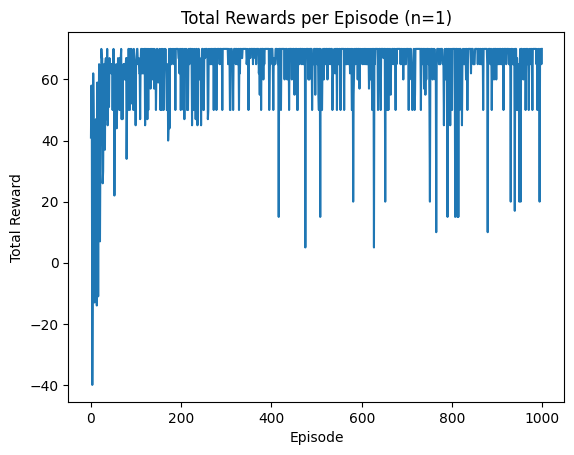

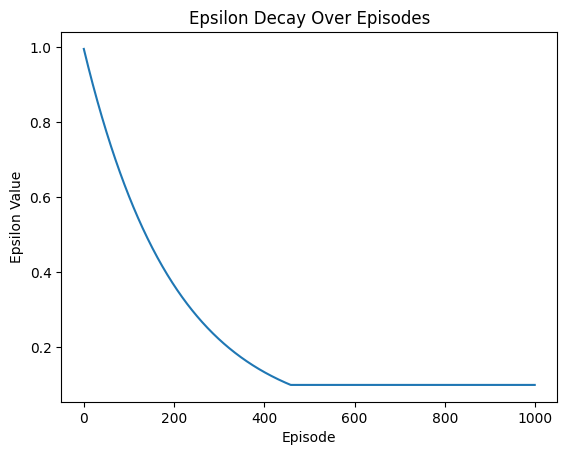

Training for n=2

Trained QA-Table:
25.657729179988337	24.232628722496404	31.857773289285795	25.456456046787373
26.610910467963134	24.72652135466672	31.008872117876617	25.646193461208604
26.195035971241253	36.540492915732855	26.465585552569312	26.608134379387423
22.33935990702442	27.769855405384664	19.93145032241432	19.14375918883039
3.7441632793351687	28.968786827431707	8.500995597089668	14.483634150076503
6.1732876795028115	22.439285638650233	3.293760058608729	4.133421103934186
8.86793532595777	8.015377594108854	29.456098016756425	4.261703244720618
26.866952644299104	23.73988170302687	34.81985121031005	22.65996164204369
29.089160105375	36.803691181556935	30.165008143463325	30.37895410884937
27.22575314189341	26.83345310919273	29.424318284715643	34.87763421431623
7.15250404395434	27.89652874370478	3.667396160640587	6.233093417052648
3.122552039958467	7.6265980816370975	26.429045666493103	3.7301547806532653
11.719823264394424	20.04904977305957	34.230590222967194	15.331992303449478
28.6

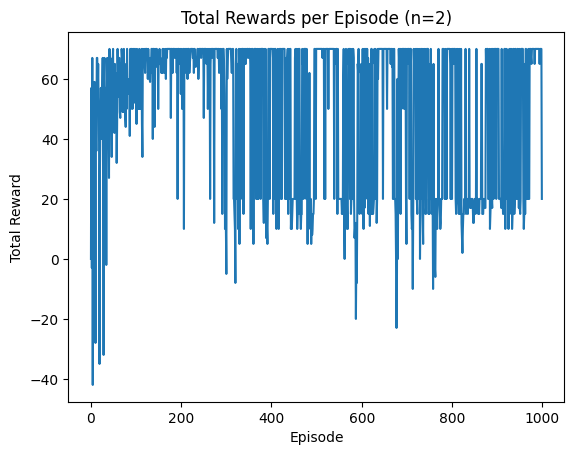

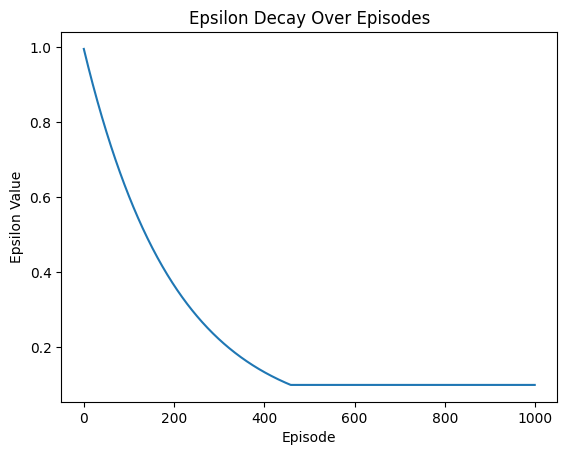

Training for n=3

Trained QA-Table:
24.84401657533674	23.41438734527029	25.873703980207004	23.853134902211654
18.77051707735554	5.720365706589968	24.719330886641714	7.3772384607472805
11.76955380122029	6.485969116265196	24.636713510948034	3.631337650489269
21.37371101947054	22.516260129069202	17.832558218238955	19.11941574698936
2.202760628530122	17.8081562129095	5.302380732134337	6.340672842758145
25.821601687185733	23.494293299078965	20.908123017212617	24.433139473746763
6.758487304777307	5.011639825926803	25.500048347989	13.240555553235765
9.504105279844438	8.308227722649399	22.0989570206807	8.32857653478647
22.127787261345148	21.953446992480536	21.455499258000888	21.430721275033267
11.28022683031409	24.178829496122557	14.01168295987016	9.524431538510884
18.900008982817234	23.443736519324954	23.028138273572953	21.57251382766628
14.32246173081672	21.042946405547617	21.896993526521396	20.443125138791682
16.294887705473915	26.11675330074347	22.7645395726308	24.298688086838762
21.892132

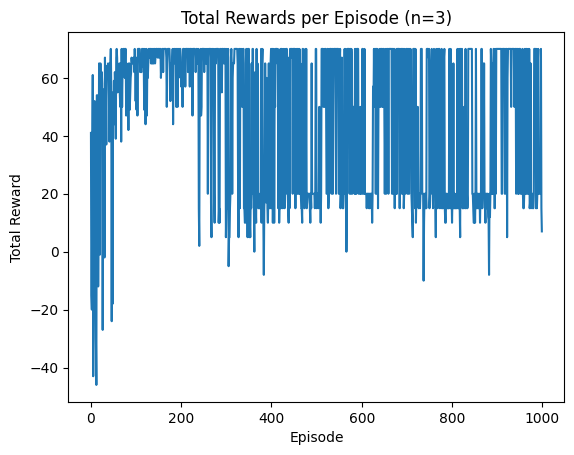

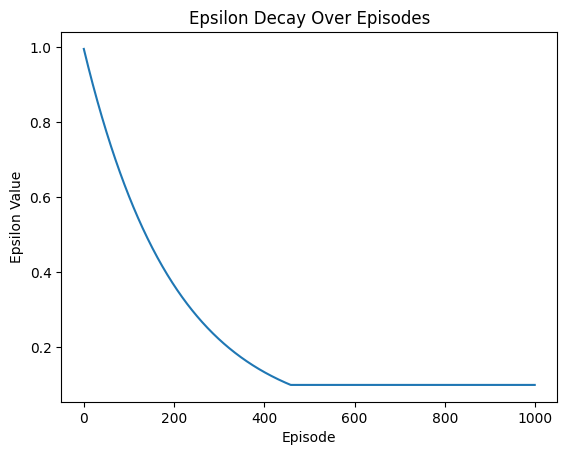

Training for n=4

Trained QA-Table:
18.48960215767383	21.958761219684003	19.191971267873118	19.08918833631599
18.240460013382513	16.838812070083335	18.784929418016755	20.07427709761858
18.661357924364637	18.418580895326254	19.38144223466791	19.928600445973927
18.37670342447081	18.6688986274214	18.522803012524232	19.518288918779323
12.21638131512937	18.393347878467935	9.73204652695306	13.183311391090033
19.79811293620565	21.869041295901617	15.56618002317873	18.52739865678727
10.03354434078059	8.11514002617207	19.71604570481683	3.2357804223766613
18.365990808024605	15.279918981757616	18.613353089209852	14.743537040153262
19.05216981687419	17.823362558458058	17.80309027344363	17.958344258616755
18.49253314907748	17.982663419813672	18.09750247978899	17.999921977859497
17.758080302469633	21.773998134987618	16.348936677584643	18.610625864248426
1.8733633959125566	6.780945272937488	18.564992173477748	5.711536040690652
20.313374969359884	18.462074238641375	24.182445878667696	15.08770905714943


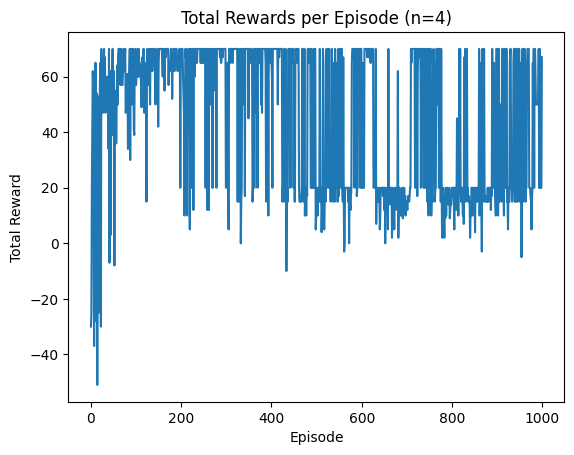

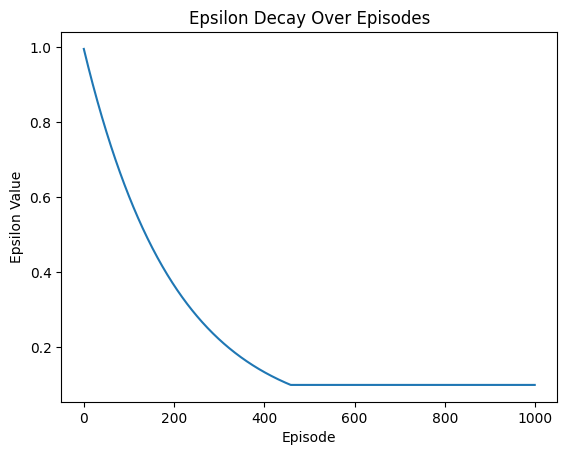

Training for n=5

Trained QA-Table:
17.84143615226843	16.28770515636435	21.146707209857897	18.87102842210019
8.313011794890135	8.033013030860628	20.394046133445066	9.979961658191545
12.36551967393982	4.556688941214031	21.334802123809943	7.049868976381171
9.44212838786025	14.646942217477156	23.120357943255037	11.210165122459479
16.898017418227212	25.04484873510699	12.568220593494988	12.917092424086935
19.91606473012381	19.5638169270697	20.422766162230786	19.63503859211066
3.088098707147518	27.45435300484858	7.285086141457503	5.689547194410972
5.15985052572051	5.101486636155337	20.87123561763376	2.210431944703563
8.264532094388034	16.047665296354502	20.876606921316714	7.64289462612861
21.013321410088782	23.752614960930632	18.029294549409556	18.456555059174086
19.120743285388738	18.52621245364179	18.532816785915905	19.73141169255893
12.654768967687454	26.325703422605528	17.843946455663573	19.615575363952168
11.515270709712576	21.78347512342245	13.090488319447942	9.754132884862468
19.10634

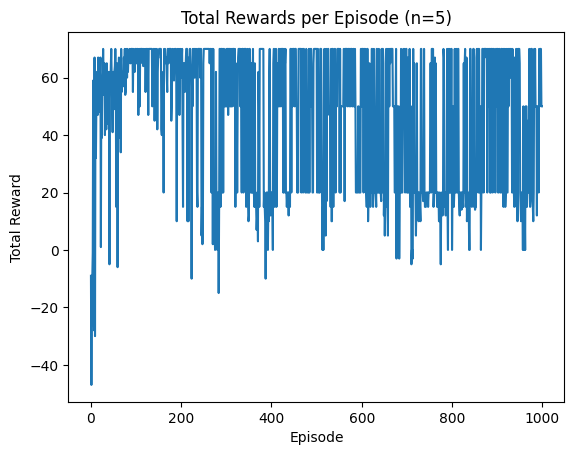

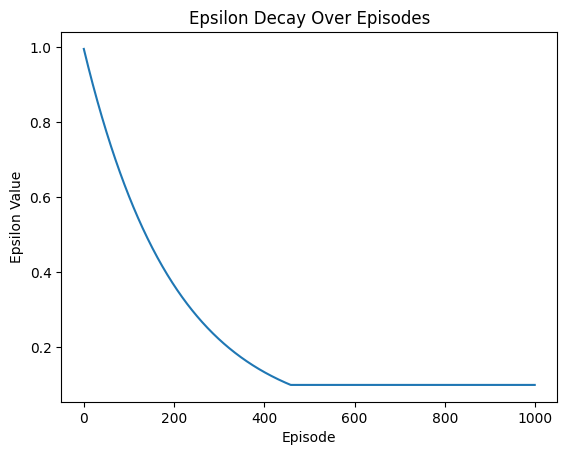

In [54]:
n_values = [1, 2, 3, 4, 5]
results = {}

for n in n_values:
    print(f"Training for n={n}")
    Q_A, Q_B, rewards_per_episode, epsilon_values = n_step_double_q_learning(env, n=n)
    print("\nTrained QA-Table:")
    printQTable(Q_A)
    print("\nTrained QB-Table:")
    printQTable(Q_B)    
    results[n] = (Q_A, Q_B, rewards_per_episode, epsilon_values)
    
    plt.figure()
    plt.plot(rewards_per_episode)
    plt.title(f"Total Rewards per Episode (n={n})")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

Testing greedy policy for n=1


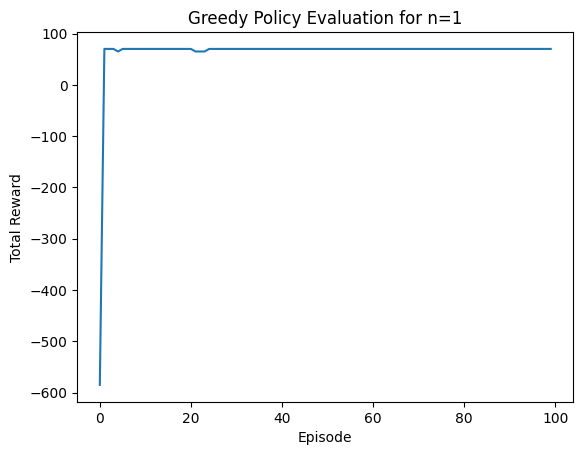

Average Greedy Reward for n=1: 63.25
Testing greedy policy for n=2


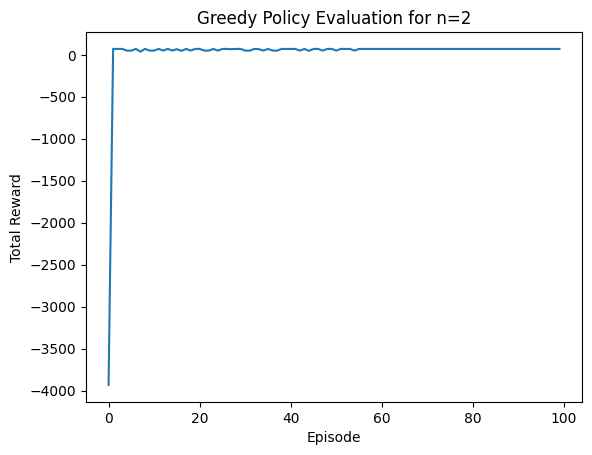

Average Greedy Reward for n=2: 25.31
Testing greedy policy for n=3


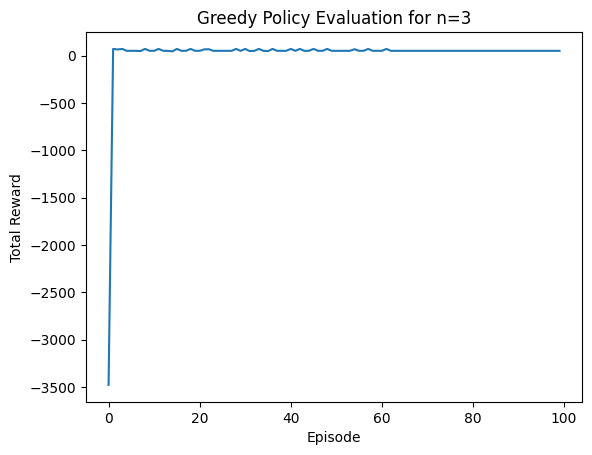

Average Greedy Reward for n=3: 18.41
Testing greedy policy for n=4


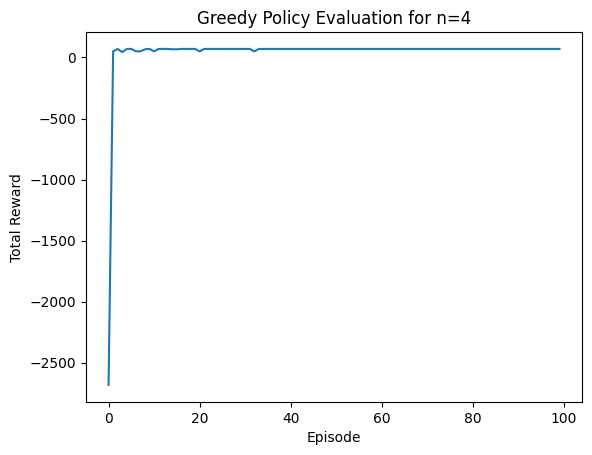

Average Greedy Reward for n=4: 40.93
Testing greedy policy for n=5


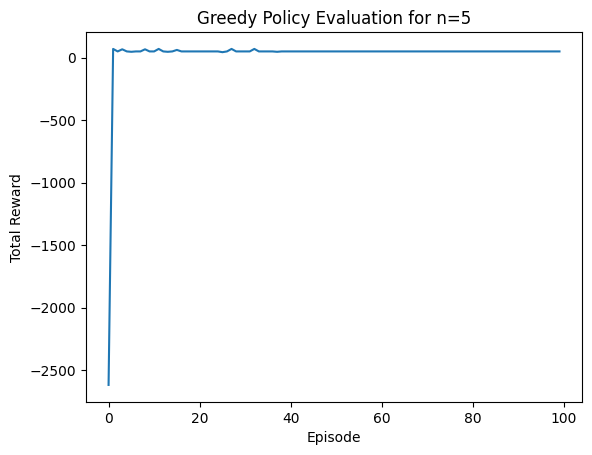

Average Greedy Reward for n=5: 24.44


In [55]:
def greedy_policy(Q, state):
    return np.argmax(Q[state, :])

num_episodes = 100
gamma = 0.99
alpha = 0.1
greedy_rewards_dq_results = {}

for n in n_values:
    print(f"Testing greedy policy for n={n}")
    Q_A, Q_B, rewards_per_episode, epsilon_values = results[n]
    greedy_rewards_dq = []

    for episode in range(num_episodes):
        state1, _ = env.reset()
        state1 = 0 
        total_reward = 0

        while True:
            action1 = greedy_policy(Q_A + Q_B, state1)
            observation, reward, done = env.step(action1)
            state2 = statesMap[tuple(observation)]
            total_reward += reward

            if np.random.rand() < 0.5:
                max_next_action = np.argmax(Q_A[state2, :])
                Q_A[state1, action1] += alpha * (reward + gamma * Q_B[state2, max_next_action] - Q_A[state1, action1])
            else:
                max_next_action = np.argmax(Q_B[state2, :])
                Q_B[state1, action1] += alpha * (reward + gamma * Q_A[state2, max_next_action] - Q_B[state1, action1])

            state1 = state2
            if done:
                break
        greedy_rewards_dq.append(total_reward)

    greedy_rewards_dq_results[n] = greedy_rewards_dq

    plt.figure()
    plt.plot(greedy_rewards_dq)
    plt.title(f"Greedy Policy Evaluation for n={n}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    print(f"Average Greedy Reward for n={n}: {np.mean(greedy_rewards_dq)}")


In [56]:
best_params = None
best_performance = float('-inf')
results = []

for alpha in [0.1, 0.01, 0.001]:
    for gamma in [0.90, 0.95, 0.99]:
        for epsilon_decay in [0.995, 0.99, 0.98]:
            Q_A, Q_B, rewards_per_episode, epsilon_values = n_step_double_q_learning(env, alpha=alpha, gamma=gamma, epsilon_decay=epsilon_decay, episodes=1000)

            avg_reward = np.mean(rewards_per_episode[-100:]) 
            results.append((alpha, gamma, epsilon_decay, avg_reward))

            print(f"Testing Alpha={alpha}, γ={gamma}, Epsilon Decay={epsilon_decay}, Reward={avg_reward}")
            if avg_reward > best_performance:
                best_performance = avg_reward
                best_params = (alpha, gamma, epsilon_decay)

print("Best Parameters:")
print(f"Alpha={best_params[0]}, γ={best_params[1]}, Epsilon Decay={best_params[2]} (Average Reward: {best_performance})")


Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.995, Reward=68.37
Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.99, Reward=68.79
Testing Alpha=0.1, γ=0.9, Epsilon Decay=0.98, Reward=69.58
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.995, Reward=68.24
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.99, Reward=68.99
Testing Alpha=0.1, γ=0.95, Epsilon Decay=0.98, Reward=68.83
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.995, Reward=59.38
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.99, Reward=59.4
Testing Alpha=0.1, γ=0.99, Epsilon Decay=0.98, Reward=63.08
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.995, Reward=68.7
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.99, Reward=69.46
Testing Alpha=0.01, γ=0.9, Epsilon Decay=0.98, Reward=69.39
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.995, Reward=68.73
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.99, Reward=69.19
Testing Alpha=0.01, γ=0.95, Epsilon Decay=0.98, Reward=69.18
Testing Alpha=0.01, γ=0.99, Epsilon Decay=0.995, Reward=68.46
Testing Alpha=0.01, γ=0.99, Epsilon

Trained QA-Table with Best Parameters:
[[ 2.21396823e+01  8.58406801e+00  3.27555775e+01  2.16982379e+01]
 [ 2.36942637e+01  9.29960231e+00  3.65481250e+01  2.29751883e+01]
 [ 2.54165066e+01  1.61571013e+01  4.08596108e+01  2.48672086e+01]
 [ 3.34520400e+01  4.56953580e+01  1.86251504e+01  3.26624794e+01]
 [ 1.41782495e+00  1.61709249e+00  0.00000000e+00  3.15639866e+01]
 [ 2.23714626e+01  0.00000000e+00 -1.22853000e+00  2.01343163e+00]
 [ 2.49172653e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.38590837e+01 -2.15260529e+00  7.93360292e-01 -8.13000000e-01]
 [ 2.67212091e+01  5.15613077e+01  2.11322069e+01  1.32801503e+01]
 [ 8.43872848e-01  0.00000000e+00  0.00000000e+00  4.05108337e+01]
 [ 0.00000000e+00  0.00000000e+00 -4.61700000e-02  0.00000000e+00]
 [-6.73070038e-01 -4.61700000e-03 -9.50000000e-01  0.00000000e+00]
 [ 0.00000000e+00  2.49421523e+01  1.10061284e-02 -2.70000000e-02]
 [ 3.31220066e+01  5.89099355e+01  2.00111960e+01  8.78701857e+00]
 [ 0.00000000e+00  0.00

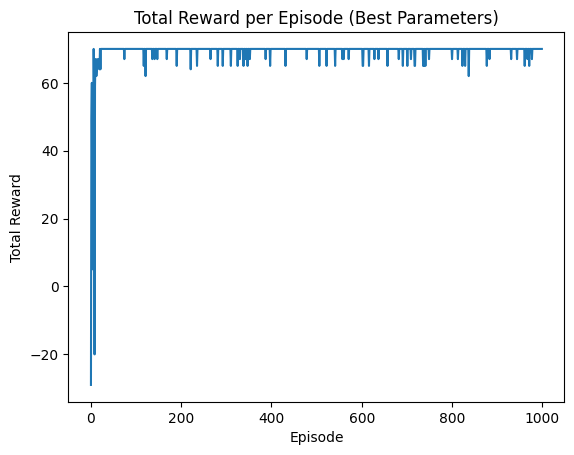

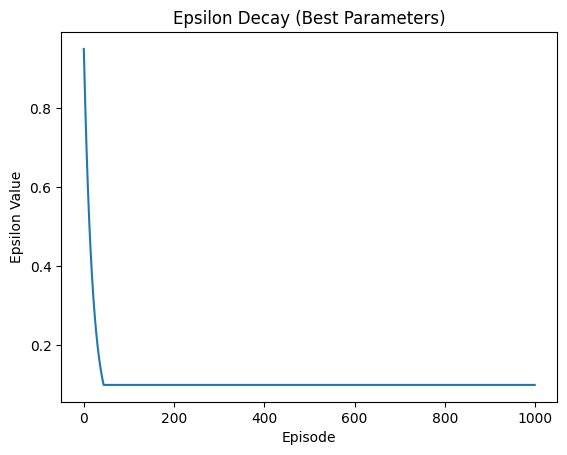

In [57]:
alpha, gamma, epsilon_decay = best_params
Q_A, Q_B, rewards_per_episode_ql, epsilon_values_ql = n_step_double_q_learning(env, gamma=gamma, epsilon_decay=0.95, episodes=1000)

print("Trained QA-Table with Best Parameters:")
print(Q_A)
print("Trained QB-Table with Best Parameters:")
print(Q_B)

plt.plot(rewards_per_episode_ql)
plt.title("Total Reward per Episode (Best Parameters)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

plt.plot(epsilon_values_ql)
plt.title("Epsilon Decay (Best Parameters)")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.show()

In [58]:

def sarsa(env, episodes=1000, alpha=0.1, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.1):

    Q = np.zeros((env.grid_size[0] * env.grid_size[1], env.action_space.n))
    
    rewards_per_episode = []
    epsilon_values = []

    for episode in range(episodes):
        state, _ = env.reset()
        state = tuple(state)
        action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q[statesMap[state]])

        total_reward = 0

        while True:

            next_state, reward, done = env.step(action)
            next_state = tuple(next_state)

            next_action = np.random.choice(env.action_space.n) if np.random.rand() < epsilon else np.argmax(Q[statesMap[next_state]])

            Q[statesMap[state]][action] += alpha * ( reward + gamma * Q[statesMap[next_state]][next_action] - Q[statesMap[state]][action] )

            state = next_state
            action = next_action
            total_reward += reward

            if done:
                break

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_per_episode.append(total_reward)
        epsilon_values.append(epsilon)

    return Q, rewards_per_episode, epsilon_values

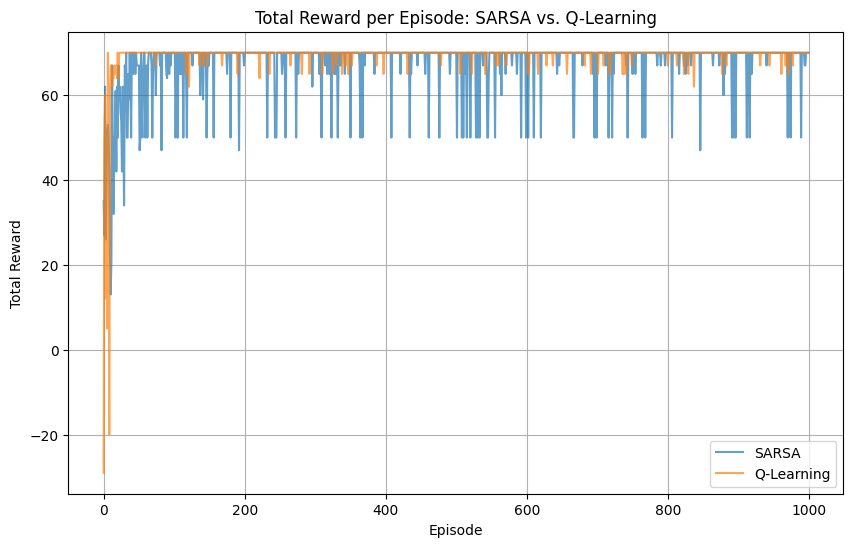

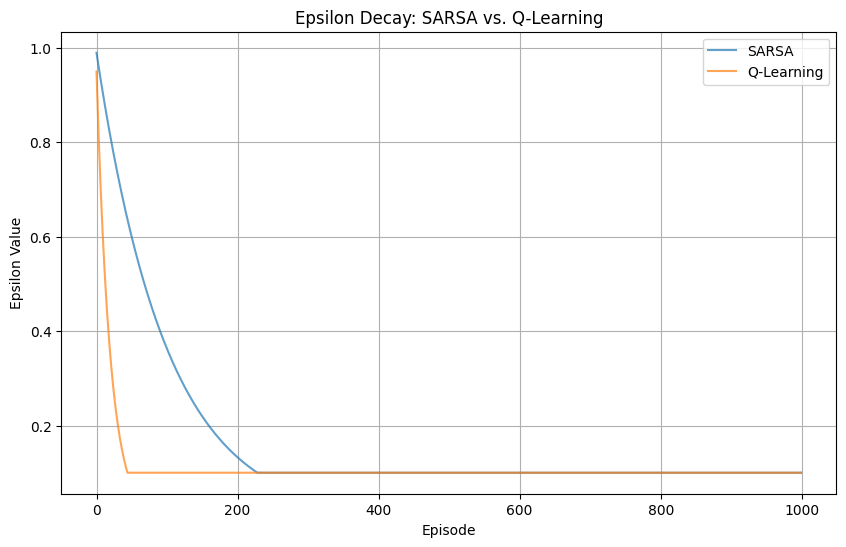

In [59]:
Q, rewards_per_episode_sarsa, epsilon_values_sarsa = sarsa(env, alpha=0.1, gamma=0.9, epsilon_decay=0.99, episodes=1000)

plt.figure(figsize=(10, 6))
plt.plot(rewards_per_episode_sarsa, label="SARSA", alpha=0.7)
plt.plot(rewards_per_episode_ql, label="Q-Learning", alpha=0.7)
plt.title("Total Reward per Episode: SARSA vs. Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epsilon_values_sarsa, label="SARSA", alpha=0.7)
plt.plot(epsilon_values_ql, label="Q-Learning", alpha=0.7)
plt.title("Epsilon Decay: SARSA vs. Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Epsilon Value")
plt.legend()
plt.grid()
plt.show()
